In [ ]:
!git clone https://github.com/fruits-360/fruits-360-100x100.git
import os
path = "/content/fruits-360-100x100"
print(os.listdir(path))

Cloning into 'fruits-360-100x100'...
remote: Enumerating objects: 187571, done.
remote: Counting objects: 100% (11149/11149), done.
remote: Compressing objects: 100% (11127/11127), done.
remote: Total 187571 (delta 33), reused 11137 (delta 22), pack-reused 176422 (from 2)
Receiving objects: 100% (187571/187571), 1.09 GiB | 34.41 MiB/s, done.
Resolving deltas: 100% (457/457), done.
Updating files: 100% (184840/184840), done.
['.git', 'LICENSE', 'README.md', 'Training', 'Test']


In [ ]:
train_path = "/content/fruits-360-100x100/Training"
test_path = "/content/fruits-360-100x100/Test"
classes = os.listdir(train_path)
print("Number of classes:", len(classes))
print("First 10 classes:", classes[:10])

Number of classes: 263
First 10 classes: ['Apple Golden 2', 'Tomato Cherry Orange 1', 'Nut 1', 'Ginger 2', 'Onion White 2', 'Apple Granny Smith 1', 'Peach 1', 'Redcurrant 1', 'Peach 5', 'Apple Red Yellow 2']


Class: Apple Golden 2
Image size: (100, 100)


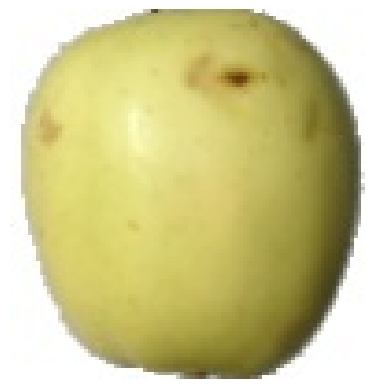

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os
class_name = classes[0]
class_path = os.path.join(train_path, class_name)
image_name = os.listdir(class_path)[0]
image_path = os.path.join(class_path, image_name)
image = Image.open(image_path)
print("Class:", class_name)
print("Image size:", image.size)
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
train_count = 0
test_count = 0
for class_name in classes:
    train_count += len(os.listdir(os.path.join(train_path, class_name)))
for class_name in os.listdir(test_path):
    test_count += len(os.listdir(os.path.join(test_path, class_name)))
print("Training images:", train_count)
print("Test images:", test_count)

Training images: 138642
Test images: 46196


In [ ]:
import os
import pandas as pd
# Count images in each class
class_counts = {}
for class_name in classes:
    class_path = os.path.join(train_path, class_name)
    class_counts[class_name] = len(os.listdir(class_path))
# Convert to DataFrame
df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number_of_Images"]
)
print(df_counts.head(10))
print("\nTotal classes:", len(df_counts))
print("Total training images:", df_counts["Number_of_Images"].sum())
print("Minimum images in a class:",
      df_counts["Number_of_Images"].min())
print("Maximum images in a class:",
      df_counts["Number_of_Images"].max())
print("Average images per class:",
      df_counts["Number_of_Images"].mean())

                    Class  Number_of_Images
0          Apple Golden 2               492
1  Tomato Cherry Orange 1               302
2                   Nut 1               241
3                Ginger 2               436
4           Onion White 2               310
5    Apple Granny Smith 1               492
6                 Peach 1               492
7            Redcurrant 1               492
8                 Peach 5               720
9      Apple Red Yellow 2               672

Total classes: 263
Total training images: 138642
Minimum images in a class: 16
Maximum images in a class: 984
Average images per class: 527.1558935361217


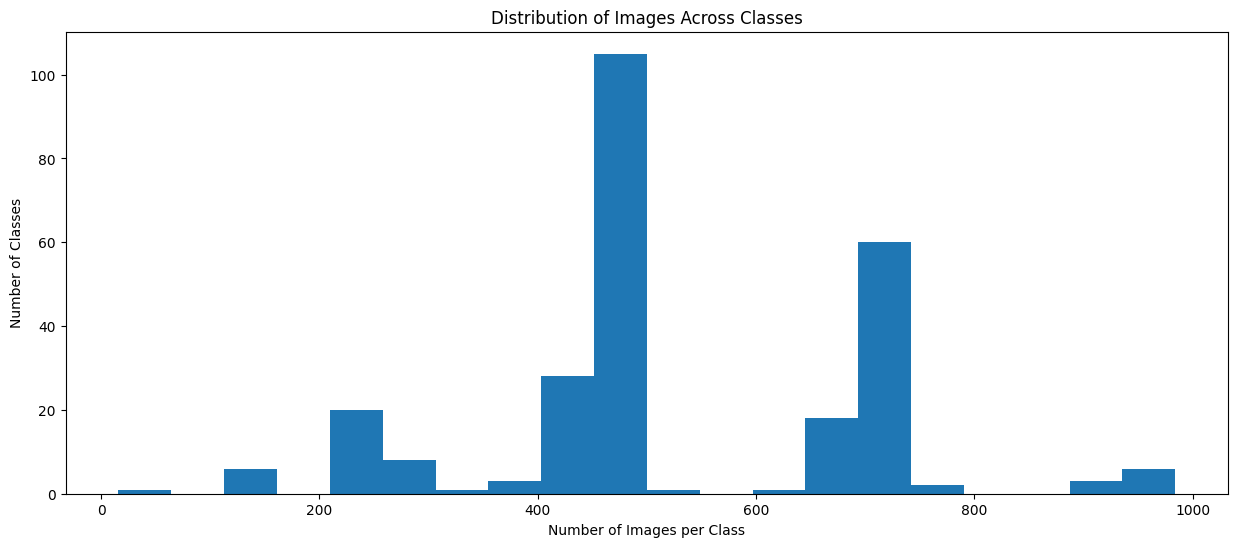

10 classes with the FEWEST images:
                 Class  Number_of_Images
184       Blackberry 3                16
45    Zucchini Green 1               144
134    Cabbage white 1               144
111      Cabbage red 1               149
218         Cucumber 1               150
252           Carrot 1               151
78   Peanut shell 1x 1               159
51              Pear 3               215
230       Blackberry 2               225
25         Caju seed 1               226


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.hist(
    df_counts["Number_of_Images"],
    bins=20
)

plt.xlabel("Number of Images per Class")
plt.ylabel("Number of Classes")
plt.title("Distribution of Images Across Classes")

plt.show()
print("10 classes with the FEWEST images:")
print(
    df_counts
    .sort_values("Number_of_Images")
    .head(10)

)

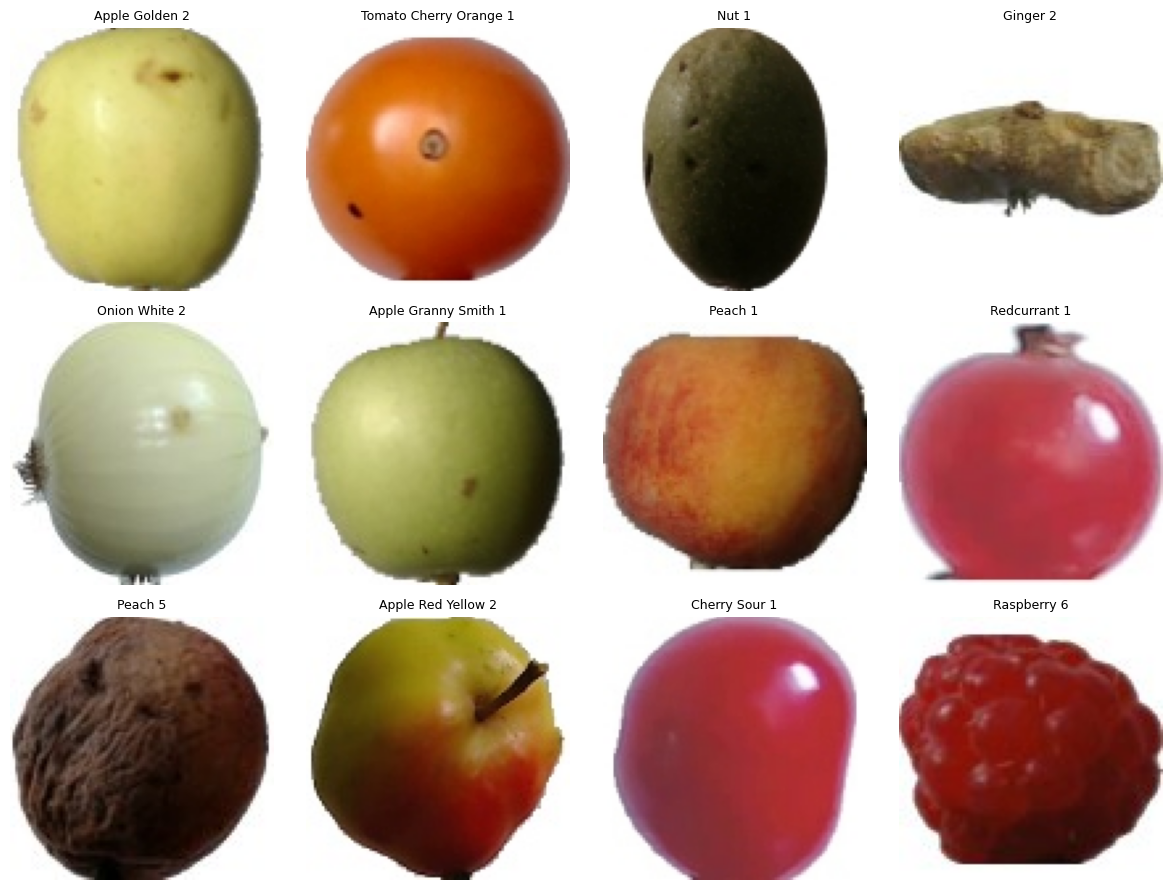

In [ ]:
import matplotlib.pyplot as plt
import os
from PIL import Image

# Choose 12 different classes
selected_classes = classes[:12]
plt.figure(figsize=(12, 9))
for i, class_name in enumerate(selected_classes):
    class_path = os.path.join(train_path, class_name)
    image_name = os.listdir(class_path)[0]
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(class_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

image_array = np.array(image)

print("Image shape:", image_array.shape)
print("Image data type:", image_array.dtype)
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

Image shape: (100, 100, 3)
Image data type: uint8
Minimum pixel value: 1
Maximum pixel value: 255


In [ ]:
import tensorflow as tf

IMG_SIZE = (100, 100)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
print("Number of classes:", len(train_dataset.class_names))
print("First 10 classes:", train_dataset.class_names[:10])
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Pixel values:", images[0].numpy().min(),
          "to",
          images[0].numpy().max())


Found 138642 files belonging to 263 classes.
Found 46196 files belonging to 263 classes.
Number of classes: 263
First 10 classes: ['Almonds 1', 'Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 20']
Images shape: (32, 100, 100, 3)
Labels shape: (32,)
Pixel values: 0.0 to 255.0


Label number: 79
Class name: Cherry Wax Red 1


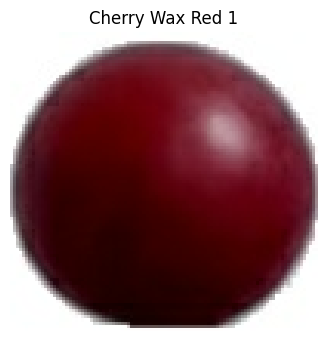

In [ ]:
import matplotlib.pyplot as plt

class_names = train_dataset.class_names

for images, labels in train_dataset.take(1):
    image = images[0]
    label = labels[0].numpy()

    print("Label number:", label)
    print("Class name:", class_names[label])

    plt.figure(figsize=(4, 4))
    plt.imshow(image.numpy().astype("uint8") if hasattr(image, "numpy") else image)
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)


train_dataset = train_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

test_dataset = test_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Pixel values:",
          images.numpy().min(),
          "to",
          images.numpy().max())


Images shape: (32, 100, 100, 3)
Pixel values: 0.0 to 1.0


In [ ]:
train_path = "/content/fruits-360-100x100/Training"
test_path = "/content/fruits-360-100x100/Test"

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (100, 100)
BATCH_SIZE = 32

cnn_train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

cnn_val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

cnn_train_generator = cnn_train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

cnn_val_generator = cnn_val_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 111003 images belonging to 263 classes.
Found 27639 images belonging to 263 classes.


In [ ]:
cnn_model = models.Sequential([


    layers.Input(shape=(100, 100, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(cnn_train_generator.num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 263)            │        67,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,437,895 (13.11 MB)

 Trainable params: 3,437,895 (13.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_history = cnn_model.fit(
    cnn_train_generator,
    validation_data=cnn_val_generator,
    epochs=10
)

Epoch 1/10
3469/3469 ━━━━━━━━━━━━━━━━━━━━ 396s 112ms/step - accuracy: 0.4964 - loss: 1.8356 - val_accuracy: 0.8686 - val_loss: 0.4182
Epoch 2/10
3469/3469 ━━━━━━━━━━━━━━━━━━━━ 374s 108ms/step - accuracy: 0.7716 - loss: 0.6691 - val_accuracy: 0.8933 - val_loss: 0.3540
Epoch 3/10
3469/3469 ━━━━━━━━━━━━━━━━━━━━ 380s 109ms/step - accuracy: 0.8271 - loss: 0.4952 - val_accuracy: 0.8877 - val_loss: 0.3220
Epoch 4/10
3469/3469 ━━━━━━━━━━━━━━━━━━━━ 386s 111ms/step - accuracy: 0.8607 - loss: 0.4015 - val_accuracy: 0.9266 - val_loss: 0.2353
Epoch 5/10
3469/3469 ━━━━━━━━━━━━━━━━━━━━ 384s 111ms/step - accuracy: 0.8817 - loss: 0.3389 - val_accuracy: 0.9374 - val_loss: 0.1806
Epoch 6/10
3469/3469 ━━━━━━━━━━━━━━━━━━━━ 381s 110ms/step - accuracy: 0.8970 - loss: 0.2931 - val_accuracy: 0.9411 - val_loss: 0.2086
Epoch 7/10
3469/3469 ━━━━━━━━━━━━━━━━━━━━ 378s 109ms/step - accuracy: 0.9091 - loss: 0.2593 - val_accuracy: 0.9480 - val_loss: 0.2075
Epoch 8/10
3469/3469 ━━━━━━━━━━━━━━━━━━━━ 377s 109ms/step - ac

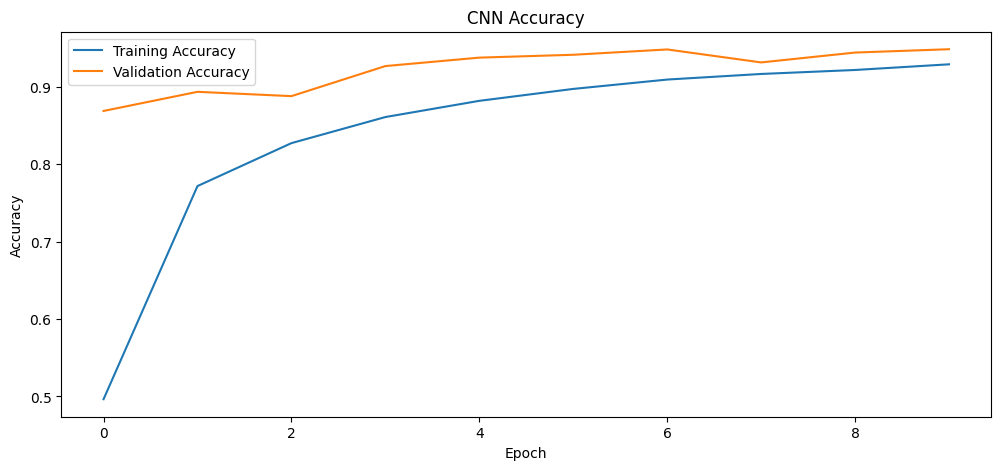

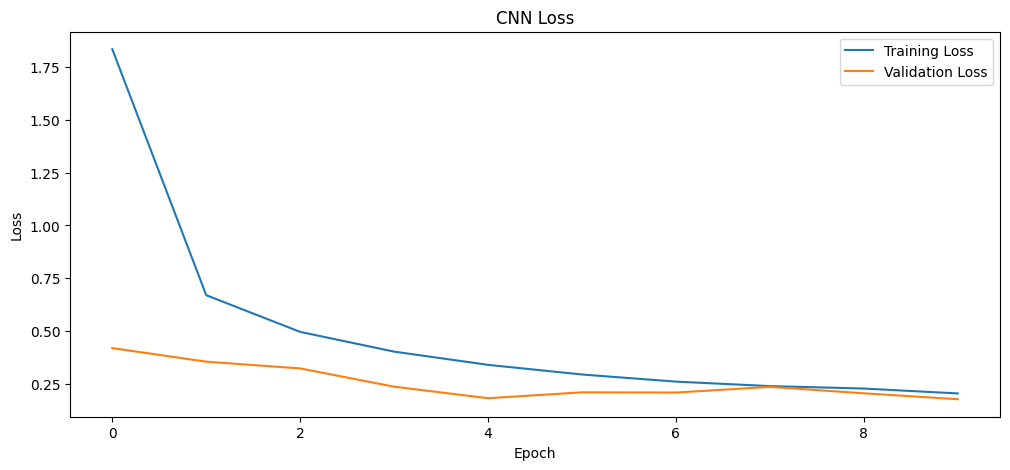

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


plt.figure(figsize=(12, 5))

plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')

plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
cnn_test_datagen = ImageDataGenerator(
    rescale=1./255
)

cnn_test_generator = cnn_test_datagen.flow_from_directory(
    test_path,
    target_size=(100, 100),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 46196 images belonging to 263 classes.


In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    cnn_test_generator
)
print(f"CNN Test Accuracy: {cnn_test_acc * 100:.2f}%")
print(f"CNN Test Loss: {cnn_test_loss:.4f}")

1444/1444 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.9582 - loss: 0.6963
CNN Test Accuracy: 95.82%
CNN Test Loss: 0.6963


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
cnn_predictions = cnn_model.predict(cnn_test_generator)

# Convert predictions to class labels
cnn_pred_classes = np.argmax(cnn_predictions, axis=1)

# True labels
cnn_true_classes = cnn_test_generator.classes

# Class names
cnn_class_names = list(cnn_test_generator.class_indices.keys())

# Classification Report
print("CNN Classification Report:")
print(
    classification_report(
        cnn_true_classes,
        cnn_pred_classes,
        target_names=cnn_class_names,
        zero_division=0
    )
)

1444/1444 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step
CNN Classification Report:
                        precision    recall  f1-score   support

             Almonds 1       1.00      1.00      1.00        77
              Apple 10       1.00      0.97      0.98       231
              Apple 11       1.00      1.00      1.00       142
              Apple 12       1.00      0.91      0.95       154
              Apple 13       1.00      1.00      1.00       235
              Apple 14       1.00      1.00      1.00       154
              Apple 17       0.98      0.95      0.96       201
              Apple 18       1.00      0.99      0.99       240
              Apple 19       0.99      1.00      1.00       241
              Apple 20       1.00      0.98      0.99       234
              Apple 21       1.00      1.00      1.00       162
              Apple 22       0.97      0.97      0.97       231
              Apple 23       1.00      0.97      0.99       156
               Apple 5       1.

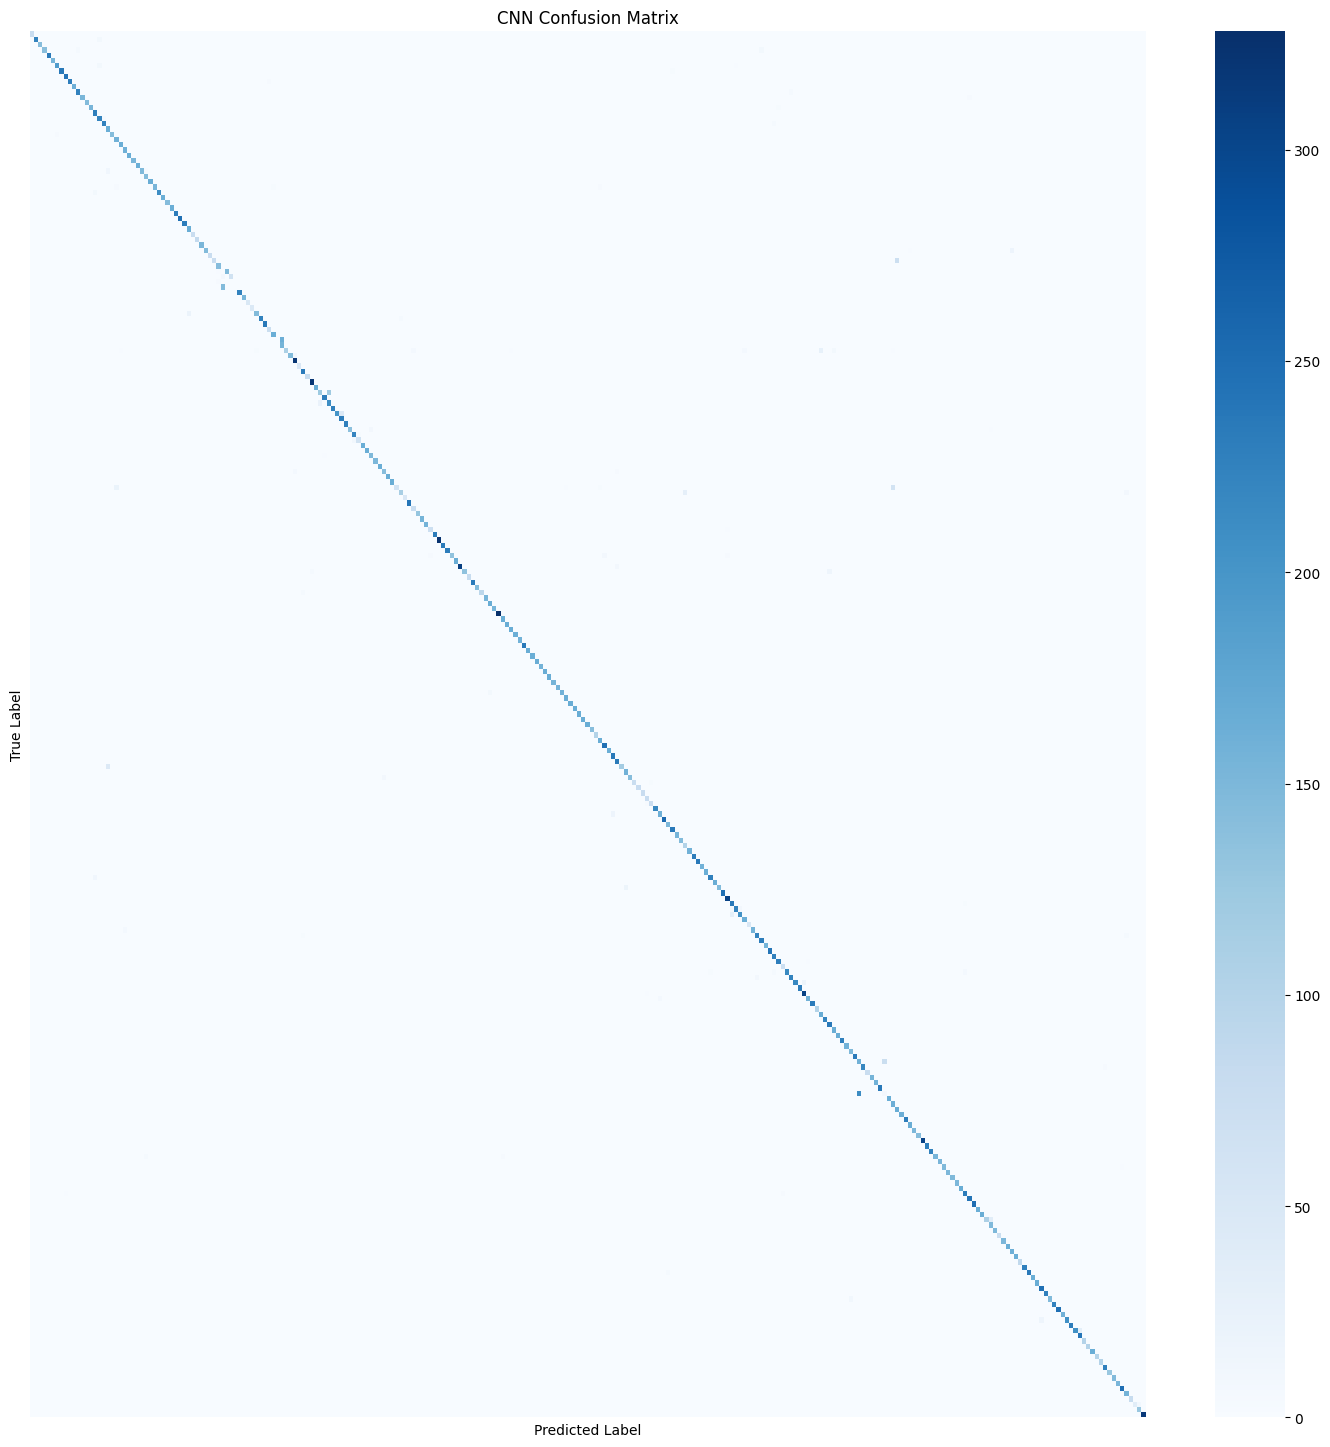

In [ ]:
cm = confusion_matrix(
    cnn_true_classes,
    cnn_pred_classes
)

plt.figure(figsize=(18, 18))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False
)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

In [ ]:
train_path = "/content/fruits-360-100x100/Training"
test_path = "/content/fruits-360-100x100/Test"

In [ ]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)


val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    validation_split=0.2
)


test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 111003 images belonging to 263 classes.
Found 27639 images belonging to 263 classes.
Found 46196 images belonging to 263 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.summary()

NameError: name 'ResNet50' is not defined

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

NameError: name 'model' is not defined

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1
)

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

In [ ]:
resnet_predictions = model.predict(test_generator)

resnet_pred_classes = np.argmax(resnet_predictions, axis=1)

resnet_true_classes = test_generator.classes

resnet_class_names = list(test_generator.class_indices.keys())

print("ResNet50 Classification Report:")
print(
    classification_report(
        resnet_true_classes,
        resnet_pred_classes,
        target_names=resnet_class_names,
        zero_division=0
    )
)

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_resnet = confusion_matrix(
    resnet_true_classes,
    resnet_pred_classes
)

plt.figure(figsize=(18, 18))

sns.heatmap(
    cm_resnet,
    cmap="Blues",
    xticklabels=False,
    yticklabels=False
)

plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
print("Model Comparison")
print("-" * 30)
print(f"CNN Accuracy:     {cnn_test_acc * 100:.2f}%")
print(f"ResNet50 Accuracy: {test_acc * 100:.2f}%")

In [ ]:

model.save("final_resnet50_fruits360.keras")

print("Final ResNet50 model saved successfully!")

In [ ]:
import json

class_names = list(test_generator.class_indices.keys())

model_info = {
    "class_names": class_names,
    "input_size": [224, 224],
    "preprocessing": "tf.keras.applications.resnet50.preprocess_input"
}

with open("resnet50_model_info.json", "w") as f:
    json.dump(model_info, f)

print("Model information saved successfully!")
print("Number of classes:", len(class_names))
print("Input size:", model_info["input_size"])
print("Preprocessing:", model_info["preprocessing"])

In [ ]:
print("Selected Final Model: ResNet50")
print("Reason: ResNet50 achieved the highest test accuracy (98.27%).")

In [ ]:
!pip install -q streamlit

In [ ]:
import os

print(os.path.exists("final_resnet50_fruits360.keras"))
print(os.path.exists("resnet50_model_info.json"))

In [ ]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import numpy as np
import json
from PIL import Image

# =========================
# Page Configuration
# =========================
st.set_page_config(
    page_title="Retail Product Recognition",
    page_icon="🛒",
    layout="centered"
)

# =========================
# Custom CSS
# =========================
st.markdown("""
<style>

.main-title {
    text-align: center;
    font-size: 42px;
    font-weight: 700;
    margin-bottom: 5px;
}

.subtitle {
    text-align: center;
    font-size: 18px;
    color: #888888;
    margin-bottom: 35px;
}

.section-title {
    font-size: 24px;
    font-weight: 600;
    margin-top: 20px;
}

.result-card {
    padding: 25px;
    border-radius: 15px;
    border: 1px solid #444444;
    margin-top: 20px;
    text-align: center;
}

.prediction {
    font-size: 32px;
    font-weight: 700;
}

.confidence {
    font-size: 20px;
    margin-top: 10px;
}

</style>
""", unsafe_allow_html=True)

# =========================
# Load Model & Model Info
# =========================
@st.cache_resource
def load_model():
    return tf.keras.models.load_model("final_resnet50_fruits360.keras")

@st.cache_data
def load_model_info():
    with open("resnet50_model_info.json", "r") as f:
        return json.load(f)

model = load_model()
model_info = load_model_info()

class_names = model_info["class_names"]

# =========================
# Header
# =========================
st.markdown(
    '<div class="main-title">🛒 Retail Product Recognition</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">'
    'AI-powered product classification using Computer Vision'
    '</div>',
    unsafe_allow_html=True
)

st.divider()

# =========================
# Upload Section
# =========================
st.markdown(
    '<div class="section-title">📷 Upload Product Image</div>',
    unsafe_allow_html=True
)

st.write(
    "Upload an image of a product and our system will "
    "identify its category."
)

uploaded_file = st.file_uploader(
    "Choose an image",
    type=["jpg", "jpeg", "png"]
)

# =========================
# Image Preview & Prediction
# =========================
if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded Product",
        use_container_width=True
    )

    st.success("Image uploaded successfully!")

    if st.button(
        "🔍 Predict Product",
        use_container_width=True
    ):

        with st.spinner("Analyzing image..."):

            # Resize image to ResNet50 input size
            img = image.resize((224, 224))

            # Convert image to NumPy array
            img_array = np.array(img)

            # Add batch dimension
            img_array = np.expand_dims(img_array, axis=0)

            # ResNet50 preprocessing
            img_array = tf.keras.applications.resnet50.preprocess_input(
                img_array
            )

            # Model prediction
            predictions = model.predict(
                img_array,
                verbose=0
            )[0]

            # Get Top 3 predictions
            top_3_indices = np.argsort(predictions)[-3:][::-1]

            # Best prediction
            top_1_index = top_3_indices[0]
            top_1_class = class_names[top_1_index]
            top_1_confidence = predictions[top_1_index] * 100

        # =========================
        # Main Result
        # =========================
        st.markdown(
            f"""
            <div class="result-card">

            <div class="prediction">
            🏆 {top_1_class}
            </div>

            <div class="confidence">
            Confidence: {top_1_confidence:.2f}%
            </div>

            </div>
            """,
            unsafe_allow_html=True
        )

        # =========================
        # Top 3 Predictions
        # =========================
        st.markdown("### 📊 Top 3 Predictions")

        col1, col2, col3 = st.columns(3)

        columns = [col1, col2, col3]

        for column, index in zip(columns, top_3_indices):

            with column:
                st.metric(
                    class_names[index],
                    f"{predictions[index] * 100:.2f}%"
                )

else:

    st.info("👆 Please upload a product image to start.")

# =========================
# Footer
# =========================
st.divider()

st.caption(
    "Retail Product Recognition System • Computer Vision Project"
)

In [ ]:
import os

print("app.py:", os.path.exists("app.py"))
print("Model:", os.path.exists("final_resnet50_fruits360.keras"))
print("Model info:", os.path.exists("resnet50_model_info.json"))

In [ ]:
!streamlit run app.py &>/content/streamlit.log &

In [ ]:
!pip install -q pyngrok

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

In [ ]:
!cloudflared tunnel --url http://localhost:8501